In [82]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
# Step 1: Set Up Parameters

# Location coordinates for London city
latitude = 51.5074
longitude = -0.1278

# Data range

start_date = '2022-01-01'
end_date = '2022-12-31'

# variable to fetch
hourly_variables = ['precipitation']


In [84]:
# Step 2: Make the API Request

base_url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'Europe/London'
}

response = requests.get(base_url, params=params)

In [85]:
# check if the request was successful

if response.status_code == 200:
    print('Data fetched successfully')
else:
    print(f'Failed to fetch data. status code:{response.status_code}')

Data fetched successfully


In [86]:
# step 3: Load Data into pandas DataFrame

data = response.json()
hourly_data  = data['hourly']

df_london = pd.DataFrame(hourly_data)
df_london.head()



,time,precipitation
0,2022-01-01T00:00,0.0
1,2022-01-01T01:00,0.0
2,2022-01-01T02:00,0.0
3,2022-01-01T03:00,0.0
4,2022-01-01T04:00,0.0


In [87]:
# Step 4: Data Cleaning
# Convert 'time' column to datetime

df_london['time'] = pd.to_datetime(df_london['time'])

# set time as the index
df_london.set_index('time',inplace = True) 

#  Check for missing values
df_london.isnull().sum()                           



precipitation    0
dtype: int64

In [88]:
# Handle missing values
df_london.fillna(method = 'ffill',inplace =True)

C:\TEmp\ipykernel_12940\4052430161.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_london.fillna(method = 'ffill',inplace =True)


In [89]:
# Step 5: Exploratory Data Analysis

# summary Statistics
df_london.describe()

,precipitation
count,8760.000000
mean,0.075662
std,0.404500
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,14.700000


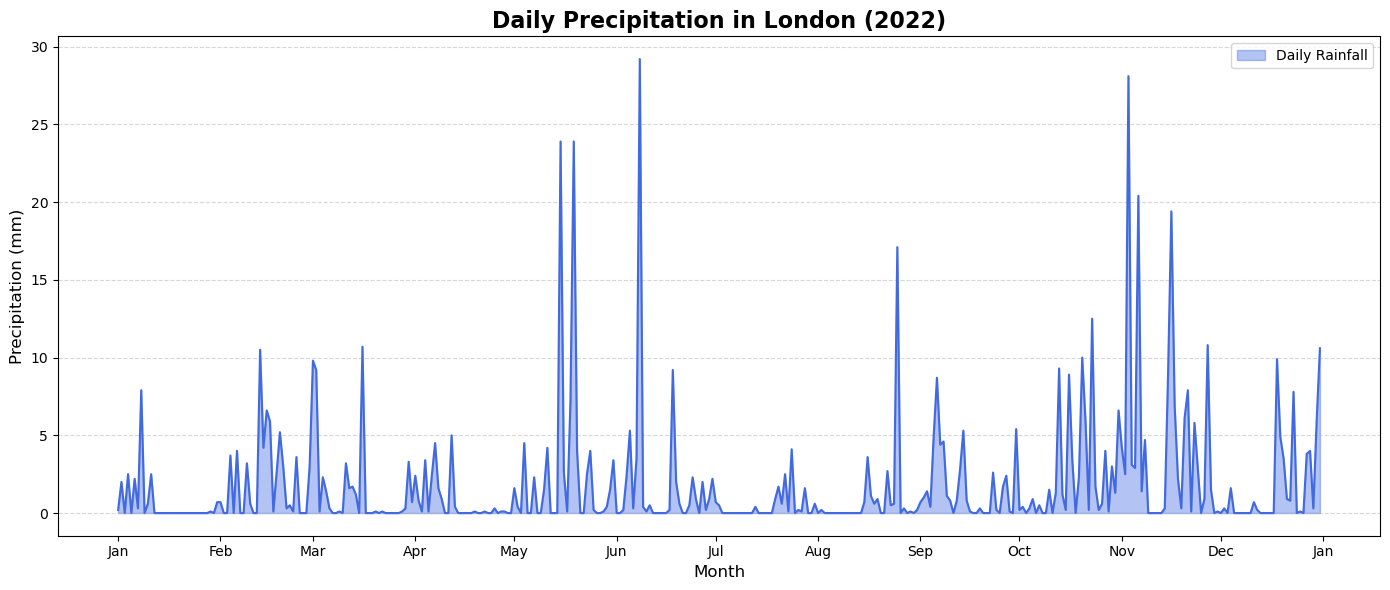

In [90]:
# Plot Precipitation Over Time

df_london_daily = df_london.resample('D').sum()

plt.figure(figsize=(14, 6))
plt.fill_between(df_london_daily.index, df_london_daily['precipitation'],
                 color='royalblue', alpha=0.4, label='Daily Rainfall')
plt.plot(df_london_daily.index, df_london_daily['precipitation'],
         color='royalblue', linewidth=1.5)

plt.title('Daily Precipitation in London (2022)', fontsize=16, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# Step 7: Resample Data to Daily Averages

lon_w = df_london.resample('W-SUN').sum()
lon_w.head()

,precipitation
time,
2022-01-02,2.2
2022-01-09,12.9
2022-01-16,3.1
2022-01-23,0.0
2022-01-30,0.1


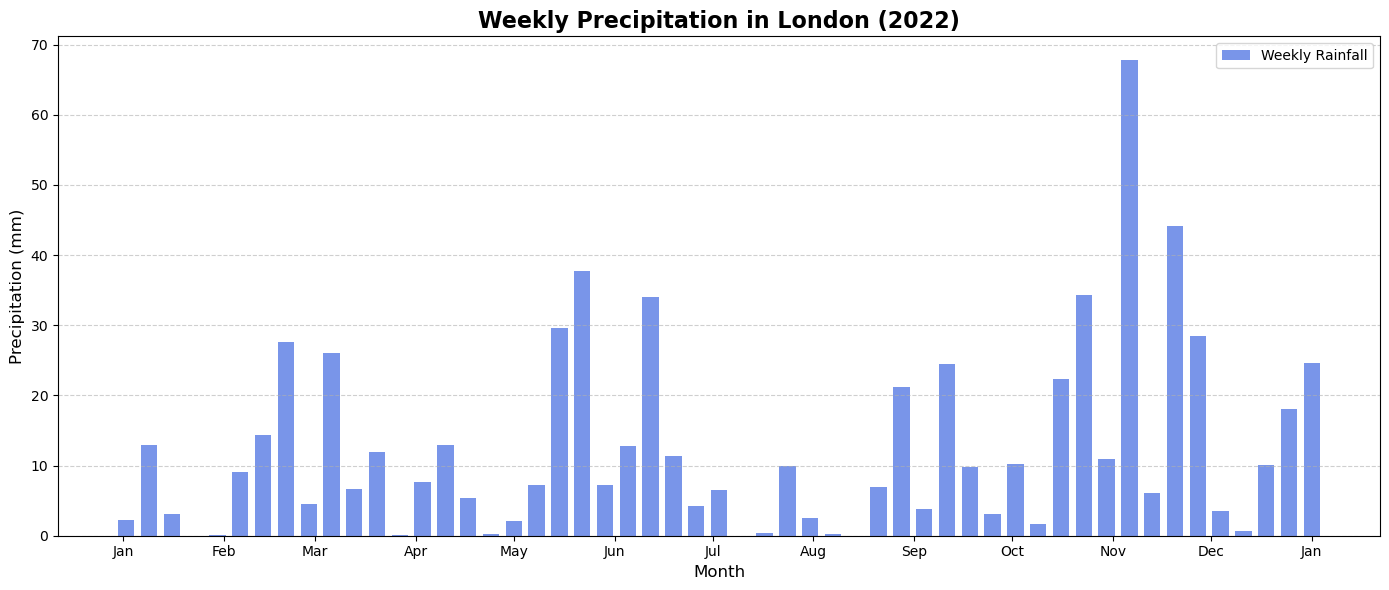

In [92]:
# weekly precipitation in london
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))
plt.bar(lon_w.index, lon_w['precipitation'],
        width=5, color='royalblue', alpha=0.7, label='Weekly Rainfall')

plt.title('Weekly Precipitation in London (2022)', fontsize=16, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)

# Format x-axis to show month names
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
#Step 8: Compare the total weekly rainfall between London and Seattle over a full year
# coordinate for seattle
latitude_se = 47.6062
longitude_se = -122.3321
hourly_variables = ['precipitation']
params_se = {
    'latitude': latitude_se,
    'longitude': longitude_se,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

response_se = requests.get(base_url, params=params_se)
# Load and clean Los Angeles data
data_se = response_se.json()
hourly_data_se = data_se['hourly']
df_se = pd.DataFrame(hourly_data_se)

df_se['time'] = pd.to_datetime(df_se['time'])
df_se.set_index('time', inplace=True)
df_se.fillna(method='ffill', inplace=True)


C:\TEmp\ipykernel_12940\1138999681.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_se.fillna(method='ffill', inplace=True)


In [94]:
sea_w = df_se.resample('W-SUN').sum()
sea_w.head()

,precipitation
time,
2022-01-02,31.3
2022-01-09,108.8
2022-01-16,45.5
2022-01-23,15.7
2022-01-30,6.1


In [95]:
# combine DataFrame for comparison

combined_rain = pd.DataFrame({
    'London' : lon_w['precipitation'],
    'Seattle' : sea_w['precipitation']
})


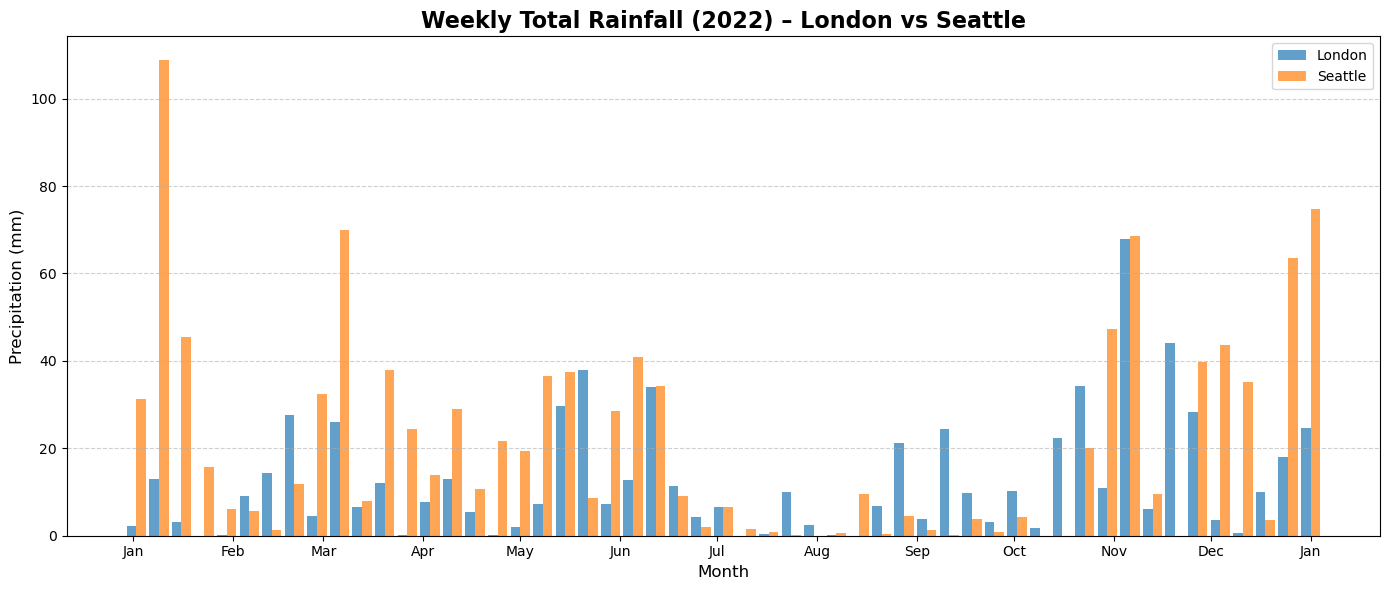

In [96]:
# plot comparison of Weekly rainfall
import matplotlib.dates as mdates
plt.figure(figsize=(14,6))

# Grouped bars: London and Seattle side by side
width = 3  # bar width in days
plt.bar(combined_rain.index - pd.Timedelta(days=width/2),
        combined_rain['London'], width=width, label='London', alpha=0.7)
plt.bar(combined_rain.index + pd.Timedelta(days=width/2),
        combined_rain['Seattle'], width=width, label='Seattle', alpha=0.7)

# Formatting
plt.title('Weekly Total Rainfall (2022) – London vs Seattle', fontsize=16, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.legend()

# X-axis ticks: show month names
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [97]:
# Advanced Analyis rainfall difference
# calculate rainfall difference
combined_rain['Rainfall Difference'] = combined_rain['London'] - combined_rain['Seattle']

combined_rain.head(10)

,London,Seattle,Rainfall Difference
time,,,
2022-01-02,2.2,31.3,-29.1
2022-01-09,12.9,108.8,-95.9
2022-01-16,3.1,45.5,-42.4
2022-01-23,0.0,15.7,-15.7
2022-01-30,0.1,6.1,-6.0
2022-02-06,9.1,5.6,3.5
2022-02-13,14.3,1.2,13.1
2022-02-20,27.6,11.9,15.7
2022-02-27,4.5,32.4,-27.9


In [98]:
lon_w = df_london.resample('W-SUN').sum()

sea_w = df_se.resample('W-SUN').sum()

weekly = lon_w.join(sea_w, how='outer',lsuffix = '_london',rsuffix = '_seattle').fillna(0.0)

lon_total = weekly['precipitation_london'].sum()
sea_total = weekly['precipitation_seattle'].sum()


more_rain = "London" if lon_total > sea_total else "Seattle"
margin = abs(lon_total - sea_total)


print(f"Total precipitation 2022 — London: {lon_total:.1f} mm, Seattle: {sea_total:.1f} mm")
print(f"More rainfall overall: {more_rain} by {margin:.1f} mm")


Total precipitation 2022 — London: 662.8 mm, Seattle: 1131.2 mm
More rainfall overall: Seattle by 468.4 mm


In [99]:
# Save Data to CSV
df_london.to_csv('london_rainfall_2022.csv')
df_se.to_csv('seattle_rainfall_2022.csv')

Conclusion
In this exercise, 

Accessed and retrieved data from the Open-Meteo API.

Cleaned and preprocessed JSON data using pandas.

Performed exploratory data analysis and visualization.

Compared rainfall patterns between New London and Seattle.